In [99]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor,
    VotingClassifier,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [100]:
airbnb = pd.read_csv('AB_NYC_2019.csv')

In [101]:
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [102]:
airbnb['average_day_rent'] = airbnb['price'] / airbnb['minimum_nights']

In [104]:
airbnb.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,average_day_rent
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327,70.174247
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289,157.620388
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000,20.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000,44.500000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000,81.500000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,8000.000000


In [105]:
airbnb['count'] = 1

### Filtering out all the houses that aren't available the whole year

In [116]:
airbnb = airbnb[airbnb['availability_365'] != 0]

# Filtering all the house prices which are 0

In [117]:
airbnb = airbnb[airbnb['price'] > 0]

# Top 10 Neighbourhoods

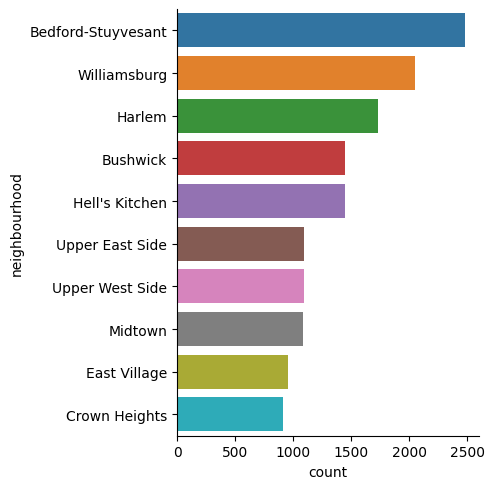

In [118]:
top10neighbourhoods = airbnb['neighbourhood'].value_counts().reset_index()[:10]

sns.catplot(
    y='neighbourhood',
    x='count',
    data=top10neighbourhoods,
    kind='bar',
    hue='neighbourhood'
)

# Mean of prices by neighbourhood

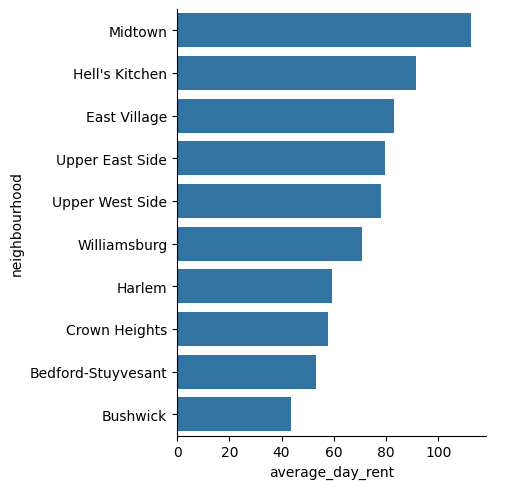

In [119]:
# newDf = airbnb[['price','neighbourhood']][airbnb['neighbourhood'].isin(top10neighbourhoods['neighbourhood'])]
# print(newDf)

newDf = airbnb[airbnb['neighbourhood'].isin(top10neighbourhoods['neighbourhood'])].groupby("neighbourhood")["average_day_rent"].mean().reset_index().sort_values(by='average_day_rent',ascending=False)
sns.catplot(
    y='neighbourhood',
    x='average_day_rent',
    kind='bar',
    data=newDf,
)

<Axes: xlabel='price', ylabel='Count'>

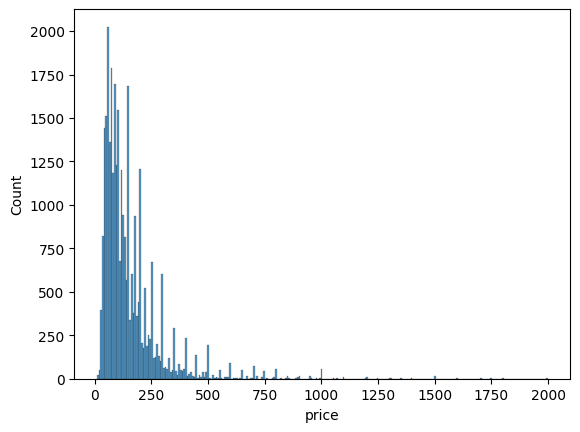

In [120]:

sns.histplot(
    x='price',
    data=airbnb[airbnb['price'] < 2000],
)

# Avg day prices by the room type

Text(0.5, 1.0, 'Number of occurences of room types')

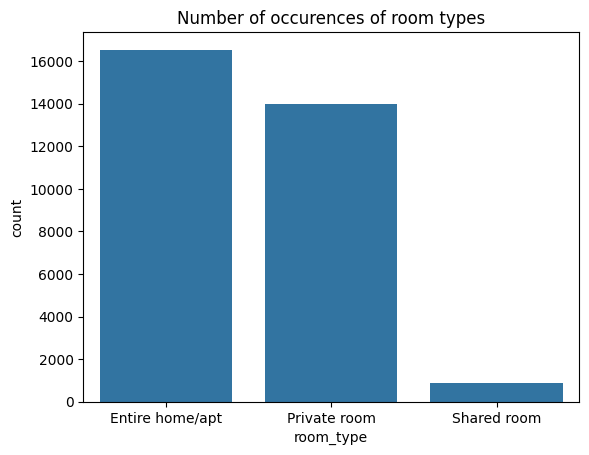

In [121]:
newDf = airbnb['room_type'].value_counts().reset_index()
sns.barplot(
    y='count',
    x='room_type',
    data=newDf
)
plt.title("Number of occurences of room types")

Text(0.5, 1.0, 'Average price for room types')

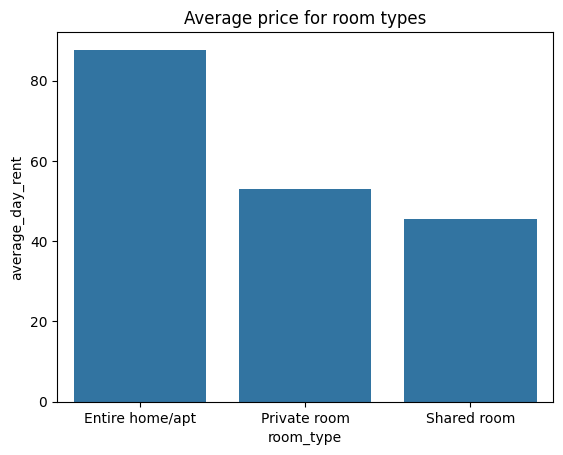

In [122]:
newDf = airbnb.groupby("room_type")["average_day_rent"].mean().reset_index().sort_values(by='average_day_rent',ascending=False)
sns.barplot(
    y='average_day_rent',
    x='room_type',
    data=newDf
)
plt.title("Average price for room types")


<Axes: xlabel='average_day_rent', ylabel='room_type'>

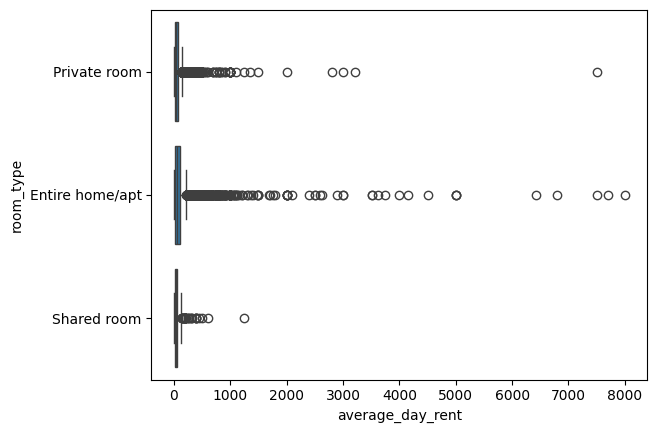

In [123]:
sns.boxplot(
    x='average_day_rent',
    y='room_type',
    data=airbnb
)

In [124]:
airbnb['average_day_rent'].describe()

count    31354.000000
mean        71.010169
std        166.588334
min          0.079079
25%         18.333333
50%         43.750000
75%         83.333333
max       8000.000000
Name: average_day_rent, dtype: float64

In [125]:
airbnb[airbnb['average_day_rent'] > 2000]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,average_day_rent,count
2698,1448703,Beautiful 1 Bedroom in Nolita/Soho,213266,Jessica,Manhattan,Nolita,40.72193,-73.99379,Entire home/apt,5000,1,2,2013-09-28,0.03,1,365,5000.0,1
4376,2952861,Photography Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69127,-73.96563,Entire home/apt,4500,1,5,2018-12-29,0.09,11,365,4500.0,1
4377,2953058,Film Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69137,-73.96723,Entire home/apt,8000,1,1,2016-09-15,0.03,11,365,8000.0,1
6620,4777903,SOHO GALLERY,1581845,Indi,Manhattan,Tribeca,40.71883,-74.00357,Entire home/apt,2400,1,2,2016-10-19,0.05,1,365,2400.0,1
20551,16348791,Spectacular Townhouse 4Floor 5BD West Village NYC,101132948,Maud,Manhattan,West Village,40.73726,-74.00085,Entire home/apt,2590,1,8,2018-12-27,0.41,1,361,2590.0,1
21821,17537893,The Otheroom Bar/Event/Filming Space -read det...,18037301,James,Manhattan,West Village,40.73571,-74.00780,Entire home/apt,4000,1,0,NaN,NaN,1,173,4000.0,1
22353,18051877,Victorian Film location,2675644,Alissa,Staten Island,Randall Manor,40.63952,-74.09730,Entire home/apt,5000,1,0,NaN,NaN,1,344,5000.0,1
22373,18071399,West Chelsea Studios - Penthouse 12,113534805,Jackie,Manhattan,Chelsea,40.74932,-74.00333,Private room,2800,1,0,NaN,NaN,1,89,2800.0,1
22992,18616208,"Modern Townhouse for Photo, Film & Daytime Ev...",55017405,Lanie,Manhattan,Upper West Side,40.77978,-73.97598,Entire home/apt,2900,1,0,NaN,NaN,1,180,2900.0,1
28727,22207357,The room boom,162116640,Tuvia,Brooklyn,Brighton Beach,40.58363,-73.96405,Private room,3000,1,0,NaN,NaN,1,90,3000.0,1
